In [2]:
import pandas as pd

# Load the dataset
df = pd.read_excel("data/Online Retail.xlsx")

# View the first 5 rows of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Save to CSV for faster loading in future sessions
df.to_csv("data/online_retail.csv", index=False)

In [4]:
# Check dataset dimensions (rows, columns)
print("Dataset Shape (Rows, Columns):", df.shape)

print("\n--- Dataset Summary & Data Types ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Numerical Column Statistics ---")
display(df.describe())

Dataset Shape (Rows, Columns): (541909, 8)

--- Dataset Summary & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

--- Missing Values Count ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--- Num

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
# Create a clean copy of the dataset
df_clean = df.copy()

# 1. Drop rows missing product descriptions
df_clean = df_clean.dropna(subset=['Description'])

# 2. Standardize product text (strip spaces, convert to uppercase)
df_clean['Description'] = df_clean['Description'].astype(str).str.strip().str.upper()

# 3. Remove cancelled orders (Invoice numbers starting with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# 4. Filter for positive Quantity and UnitPrice
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 5. Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

print(f"Original row count: {len(df)}")
print(f"Cleaned row count:  {len(df_clean)}")

Original row count: 541909
Cleaned row count:  524878


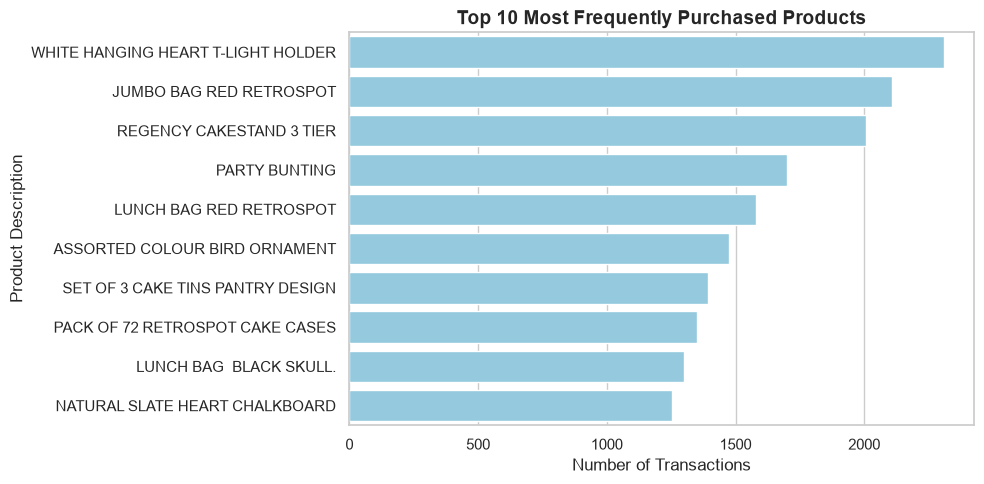

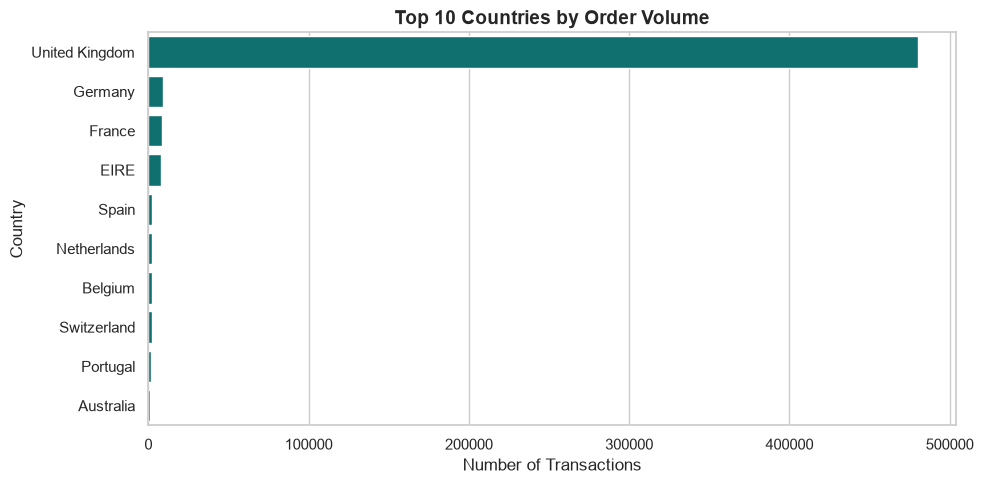

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create images folder to save charts for GitHub portfolio
os.makedirs('images', exist_ok=True)
sns.set_theme(style="whitegrid")

# Chart 1: Top 10 Products
plt.figure(figsize=(10, 5))
top_products = df_clean['Description'].value_counts().head(10)
sns.barplot(x=top_products.values, y=top_products.index, color="skyblue")
plt.title("Top 10 Most Frequently Purchased Products", fontsize=14, fontweight='bold')
plt.xlabel("Number of Transactions")
plt.ylabel("Product Description")
plt.tight_layout()
plt.savefig("images/top_10_products.png", dpi=300)
plt.show()

# Chart 2: Top 10 Countries
plt.figure(figsize=(10, 5))
top_countries = df_clean['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, color="teal")
plt.title("Top 10 Countries by Order Volume", fontsize=14, fontweight='bold')
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("images/top_10_countries.png", dpi=300)
plt.show()

In [10]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Pivot UK transactions into a basket matrix
basket = (df_clean[df_clean['Country'] == "United Kingdom"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# 2. Convert quantities > 0 to True/False booleans
basket_sets = basket.map(lambda x: True if x > 0 else False)

# 3. Find frequent itemsets using Apriori algorithm
frequent_itemsets = apriori(basket_sets, min_support=0.02, use_colnames=True)

# 4. Generate association rules based on Lift score
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by='lift', ascending=False)

# Display top 10 rules
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

,antecedents,consequents,support,confidence,lift
193,(WOODEN STAR CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.020423,0.768267,27.197263
192,(WOODEN HEART CHRISTMAS SCANDINAVIAN),(WOODEN STAR CHRISTMAS SCANDINAVIAN),0.020423,0.722986,27.197263
195,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.027305,0.702857,18.041001
198,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.027305,0.700855,18.041001
197,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.027305,0.527897,17.453534
196,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.027305,0.902752,17.453534
194,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER),0.027305,0.854167,16.099612
199,(ROSES REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.027305,0.514644,16.099612
33,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.031966,0.820513,15.863541
32,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.031966,0.618026,15.863541


In [11]:
# Format frozen sets into clean string lists for export
rules_export = rules.copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))

# Save top association rules to CSV
rules_export.to_csv("data/association_rules.csv", index=False)
print("Association rules successfully saved to 'data/association_rules.csv'!")

Association rules successfully saved to 'data/association_rules.csv'!


## Business Insights & Recommendations

1. **Product Bundling:** Create discounted product bundles for complimentary items like the **Scandinavian Wooden Star & Heart** set or the **Regency Teacup Color Trio (Green, Pink, Roses)**.
2. **Cross-Selling & Recommendations:** Configure the online store engine to display "Frequently Bought Together" prompts whenever a customer adds a Regency Teacup variant to their cart.
3. **Inventory Management:** Ensure matching Regency items are stocked together in warehouse zones to streamline order picking and fulfillment.